# EGFR KD Analysis
This notebook loads all the summary CSVs, merges them with a dataset column, and plots a grid of KD value histograms.

In [96]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_dir = "/users/nferruz/fstocco/Desktop/EGFR_analysis/EGFR_final_analysis/input_data"
all_files = glob.glob(os.path.join(base_dir, "EGFR_round*", "*summary*.csv"))

df_list = []
for file in all_files:
    dataset_name = os.path.basename(os.path.dirname(file))
    df = pd.read_csv(file)
    df['dataset'] = dataset_name
    df['round'] = dataset_name.split("_")[1].replace("round","")
    df['buffer'] = dataset_name.split("_")[-1] if len(dataset_name.split("_"))==3 else "standard"
    df_list.append(df)

merged_df = pd.concat(df_list, ignore_index=True)
merged_df['kd'] = pd.to_numeric(merged_df['kd'], errors='coerce')

merged_df.to_csv("/users/nferruz/fstocco/Desktop/EGFR_analysis/EGFR_final_analysis/merged_summary.csv", index=False)

def gmean_keep_na(s):
    # we do geometric mean because of the log scale
    s = s.dropna()
    # if no valid values in the group, keep NA
    if s.empty:
        return np.nan
    # geometric mean only defined for positive values
    s = s[s > 0]
    if s.empty:
        return np.nan
    return np.exp(np.mean(np.log(s)))

keys = ["dataset", "sequence"]   # example: only these define the group
vals = ["kd", "kon", "koff"]
meta = ["round", "expression","binding_strength", "confidence", "method", "buffer"]

avg_df = (
    merged_df
    .groupby(keys, as_index=False)
    .agg({**{c: "first" for c in meta}, **{c: gmean_keep_na for c in vals}})
)

avg_df["entry"] = avg_df.groupby("dataset").cumcount()
avg_df.head()
merged_df.head()

,name,replicate,expression,binding,kd,kon,koff,sequence,binding_strength,confidence,method,dataset,round,buffer
0,1.3.3.18_2365_0_round_2,1,high,True,2.320170e-07,52631.542902,0.012211,PNSTERCPPSHDSYCLNGGVCIFFSVLQEFACKCLQGYMGERCQHS...,medium,high,BLI,EGFR_round5,5,standard
1,1_3_3_18_406_0_round_3.3,1,medium,True,3.396309e-08,180767.513073,0.006139,SSTVQSCPSSHDTYCLYGGVCFYIPEMESFACNCLKGYMGERCQFS...,strong,high,BLI,EGFR_round5,5,standard
2,1.3.3.18_2431_12_round_2,1,high,True,1.073132e-07,95397.021330,0.010237,TAPESNYCLNETVIDCPTSHDTFCLYDGTCMFIPEMEKYACNCLAG...,medium,high,BLI,EGFR_round5,5,standard
3,1_3_3_18_838_12_round_3.1,1,high,True,7.356532e-07,15653.033896,0.011515,NPSDSVAGSTRPGLAEPCPMEYYSPYCLHGECKFIKELSSYACNCV...,medium,low,BLI,EGFR_round5,5,standard
4,1.3.3.18_1598_1_round_2,1,medium,True,NaN,NaN,NaN,NSVETCPSTYCLHGGICMFIEAVDRYACKCVVGYVGERCQYRDLRWWS,weak,high,BLI,EGFR_round5,5,standard


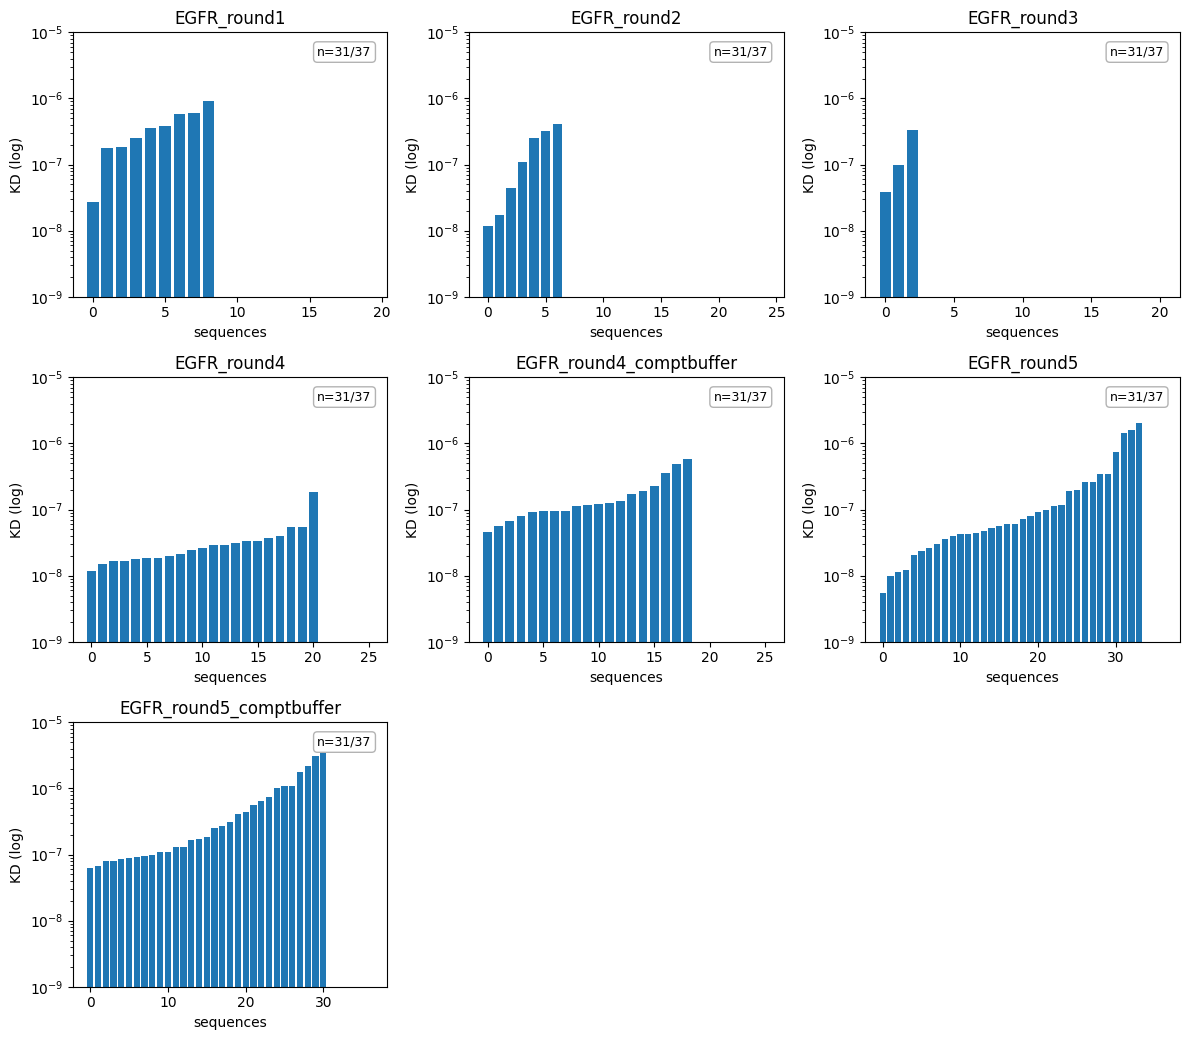

In [69]:
import numpy as np
import matplotlib.pyplot as plt

df = avg_df.copy()
datasets = df["dataset"].unique()

ncols = 3
nrows = int(np.ceil(len(datasets) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows), squeeze=False)

for i, ds in enumerate(datasets):
    ax = axes[i // ncols, i % ncols]
    sub = df[df["dataset"] == ds].copy()

    # order by kd (NaNs last)
    sub = sub.sort_values("kd", ascending=True, na_position="last").reset_index(drop=True)

    x = np.arange(len(sub))
    y = sub["kd"].to_numpy()

    missing = ~np.isfinite(y)              # True for NaN / inf
    n_present = np.sum(~missing)           # count real kd values

    heights = np.where(missing, 1.0, y)    # dummy positive height so bar() works with log
    bars = ax.bar(x, heights)

    # hide ONLY missing bars
    for b, miss in zip(bars, missing):
        if miss:
            b.set_alpha(0.0)
            b.set_edgecolor("none")

    ax.set_yscale("log")
    ax.set_title(ds)
    ax.set_xlabel("sequences")
    ax.set_ylabel("KD (log)")
    ax.set_ylim(1e-9, 1e-5)

    # "legend" as a small box
    ax.text(
        0.95, 0.95,
        f"n={n_not_fill}/{n_total}",
        transform=ax.transAxes,
        va="top", ha="right",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.7"),
        fontsize=9
    )

# hide unused axes
for j in range(i + 1, nrows * ncols):
    axes[j // ncols, j % ncols].axis("off")

plt.tight_layout()
plt.savefig("plots/barplots_all_experiments.png",dpi=600)
plt.show()

In [97]:
avg_df

,dataset,sequence,round,expression,binding_strength,confidence,method,buffer,kd,kon,koff,entry
0,EGFR_round1,ANVVLDSSPLETCPSTHESYCLYGGKCRFIIQEEMPACRCMKGYDG...,1,high,none,NaN,BLI,standard,NaN,NaN,NaN,0
1,EGFR_round1,APDADVRLGAGNGTGSECPASYCFKNGTCIFYEPANEFACQCAQGY...,1,low,none,NaN,BLI,standard,NaN,NaN,NaN,1
2,EGFR_round1,ASGNPCPMPESYCLHGGVCFYFPDMQSFACRCVSGYIGERCQFSDL...,1,high,none,NaN,BLI,standard,NaN,NaN,NaN,2
3,EGFR_round1,GNSAETSRCPASHDTYCLNGGTCTFYEAVGELICQCAEGYKGKRCE...,1,high,none,NaN,BLI,standard,NaN,NaN,NaN,3
4,EGFR_round1,MSTPLATLAAASTAGRPCPTEFNPYCLHDGVCIYIPELQKYACDCV...,1,medium,none,NaN,BLI,standard,NaN,NaN,NaN,4
...,...,...,...,...,...,...,...,...,...,...,...,...
187,EGFR_round5_comptbuffer,SNTVQRCPSSHDAYCLYGGVCFYIPEMESFACKCVKGFVGERCQFS...,5,high,medium,high,BLI,comptbuffer,8.706071e-08,115297.079658,0.010038,32
188,EGFR_round5_comptbuffer,SSTVQSCPSSHDTYCLYGGVCFYIPEMESFACNCLKGYMGERCQFS...,5,medium,medium,high,BLI,comptbuffer,8.870619e-08,151169.782534,0.013410,33
189,EGFR_round5_comptbuffer,STPLNDCPPSHDAYCLYEGICFYFPEMESFACNCVKGYMGERCQFS...,5,medium,medium,high,BLI,comptbuffer,1.078774e-07,182132.111538,0.019648,34
190,EGFR_round5_comptbuffer,TAEEDKCPPSHESYCLFHGVCRFIEELNLYSCNCIKGFAGERCQFS...,5,high,weak,low,BLI,comptbuffer,NaN,NaN,NaN,35


In [109]:
# Print table for publication: 

avg_df_pub= avg_df[["round","koff", "kon", "kd", "sequence", "expression","confidence", "buffer"]]


def sci_tex(x, sig=2):
    if pd.isna(x):
        return ""
    if x == 0:
        return "0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10 ** exp)
    return rf"${mant:.{sig}f}\times 10^{{{exp}}}$"

cols_sci = ["kd", "kon", "koff"]
formatters = {c: (lambda v, c=c: sci_tex(v, sig=2)) for c in cols_sci}

latex = avg_df_pub.to_latex(
    longtable=True,
    index=False,
    formatters=formatters,
    na_rep="-",
    caption="test",
    label="test",
    escape=False,       # IMPORTANT so \times prints correctly

)
print(latex)

\begin{longtable}{lrrrllll}
\caption{test} \label{test} \\
\toprule
round & koff & kon & kd & sequence & expression & confidence & buffer \\
\midrule
\endfirsthead
\caption[]{test} \\
\toprule
round & koff & kon & kd & sequence & expression & confidence & buffer \\
\midrule
\endhead
\midrule
\multicolumn{8}{r}{Continued on next page} \\
\midrule
\endfoot
\bottomrule
\endlastfoot
1 & - & - & - & ANVVLDSSPLETCPSTHESYCLYGGKCRFIIQEEMPACRCMKGYDGARCE & high & - & standard \\
1 & - & - & - & APDADVRLGAGNGTGSECPASYCFKNGTCIFYEPANEFACQCAQGYMGERCQFSDLEWWSR & low & - & standard \\
1 & - & - & - & ASGNPCPMPESYCLHGGVCFYFPDMQSFACRCVSGYIGERCQFSDLEWWA & high & - & standard \\
1 & - & - & - & GNSAETSRCPASHDTYCLNGGTCTFYEAVGELICQCAEGYKGKRCENKDV & high & - & standard \\
1 & - & - & - & MSTPLATLAAASTAGRPCPTEFNPYCLHDGVCIYIPELQKYACDCVRGYMGERCQFSDLQWWELR & medium & - & standard \\
1 & $1.29\times 10^{-2}$ & $3.56\times 10^{4}$ & $3.62\times 10^{-7}$ & NSVERCPSSHDTYCLYGGVCFYYPETDSFACQCVNGYLGERCQYADLEWWE & high 

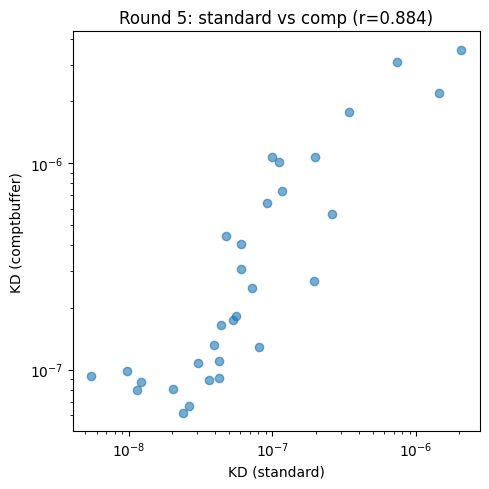

In [87]:
import numpy as np
import matplotlib.pyplot as plt

# 1) filter round
plot = avg_df[avg_df["round"] == "5"].copy()

# 2) split by buffer
std  = plot[plot["buffer"] == "standard"][["sequence", "kd"]].rename(columns={"kd": "kd_std"})
comp = plot[plot["buffer"] == "comptbuffer"][["sequence", "kd"]].rename(columns={"kd": "kd_comp"})

paired = std.merge(comp, on=[ "sequence"], how="inner")

paired = paired.dropna(subset=["kd_std", "kd_comp"])
paired = paired[(paired["kd_std"] > 0) & (paired["kd_comp"] > 0)]

x = np.log10(paired["kd_std"].to_numpy())
y = np.log10(paired["kd_comp"].to_numpy())
r = np.corrcoef(x, y)[0, 1]

plt.figure(figsize=(5, 5))
plt.scatter(paired["kd_std"], paired["kd_comp"], alpha=0.6)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("KD (standard)")
plt.ylabel("KD (comptbuffer)")
plt.title(f"Round 5: standard vs comp (r={r:.3f})")
plt.tight_layout()
plt.savefig("plots/corr_comp_std_round5.png", dpi=600)
plt.show()